## imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import os


## Getting the World happiness Data

1. Downloaded the world hapiness data and convered it into one big padnas dictionary using concat(), can do this since all columns will be the same so it just stacks them 
2. removed individua indexes as we would have multiple rows labled as 0....
3. 

In [2]:
years = {
    2026: "Happiness_Data/WHR26_Data_Figure_2.1.xlsx",
    2025: "Happiness_Data/WHR25_Data_Figure_2.1v3.xlsx",
    2024: "Happiness_Data/WHR24_Data_Figure_2.1.xls",
    2023: "Happiness_Data/WHR23_Data_Figure_2.1.xls",
    2022: "Happiness_Data/WHR22_Data_Figure_2.1.xls",
}

happiness_frames = []
for year, path in years.items():
    df = pd.read_excel(path)
    df['report_year'] = year
    happiness_frames.append(df)

happiness = pd.concat(happiness_frames, ignore_index=True)
happiness.head()



,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Generosity,Perceptions of corruption,Ladder score in Dystopia,RANK,Country,Happiness score,Whisker-high,Whisker-low,Dystopia (1.83) + residual,Explained by: GDP per capita
0,2025.0,1.0,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025.0,2.0,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025.0,3.0,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025.0,4.0,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025.0,5.0,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [3]:
#happiness.info()

In [4]:
#happiness.describe()

In [5]:
if happiness.duplicated().sum() == 0:
    print("No Duplicates")
else:
    print(happiness.duplicated().sum())


No Duplicates


In [6]:
happiness.isnull().sum()

Year                                           427
Rank                                           427
Country name                                   147
Life evaluation (3-year average)               427
Lower whisker                                 2615
Upper whisker                                 2615
Explained by: Log GDP per capita              2344
Explained by: Social support                  2198
Explained by: Healthy life expectancy         2204
Explained by: Freedom to make life choices    2201
Explained by: Generosity                      2198
Explained by: Perceptions of corruption       2200
Dystopia + residual                           2355
report_year                                      0
Ladder score                                  4232
upperwhisker                                  4232
lowerwhisker                                  4232
Standard error of ladder score                4375
Logged GDP per capita                         4375
Social support                 

## Null values investigation 

Lots of null values here but since lots of rows have the same numbe rof null values it makes me think that its column naming mismatch between the years causing lots of nulls when the concat stuck teh tables together.

So I need to standarse the header namings and see how headers lin eup in each table 


In [7]:
for year, path in years.items():
    df = pd.read_excel(path)
    print(year, list(df.columns))

2026 ['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
2025 ['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
2024 ['Country name', 'Ladder score', 'upperwhisker', 'lowerwhisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of cor

It's clearly a mess so going to use AI to help me map the right columns together

In [8]:
rename_maps = {
    2026: {
        'Country name': 'country', 'Life evaluation (3-year average)': 'happiness_score',
        'Rank': 'rank', 'Lower whisker': 'whisker_low', 'Upper whisker': 'whisker_high',
        'Explained by: Log GDP per capita': 'gdp_explained',
        'Explained by: Social support': 'social_support_explained',
        'Explained by: Healthy life expectancy': 'life_expectancy_explained',
        'Explained by: Freedom to make life choices': 'freedom_explained',
        'Explained by: Generosity': 'generosity_explained',
        'Explained by: Perceptions of corruption': 'corruption_explained',
        'Dystopia + residual': 'dystopia_residual',
    },
    2025: {  # same shape as 2026
        'Country name': 'country', 'Life evaluation (3-year average)': 'happiness_score',
        'Rank': 'rank', 'Lower whisker': 'whisker_low', 'Upper whisker': 'whisker_high',
        'Explained by: Log GDP per capita': 'gdp_explained',
        'Explained by: Social support': 'social_support_explained',
        'Explained by: Healthy life expectancy': 'life_expectancy_explained',
        'Explained by: Freedom to make life choices': 'freedom_explained',
        'Explained by: Generosity': 'generosity_explained',
        'Explained by: Perceptions of corruption': 'corruption_explained',
        'Dystopia + residual': 'dystopia_residual',
    },
    2024: {
        'Country name': 'country', 'Ladder score': 'happiness_score',
        'upperwhisker': 'whisker_high', 'lowerwhisker': 'whisker_low',
        'Explained by: Log GDP per capita': 'gdp_explained',
        'Explained by: Social support': 'social_support_explained',
        'Explained by: Healthy life expectancy': 'life_expectancy_explained',
        'Explained by: Freedom to make life choices': 'freedom_explained',
        'Explained by: Generosity': 'generosity_explained',
        'Explained by: Perceptions of corruption': 'corruption_explained',
        'Dystopia + residual': 'dystopia_residual',
    },
    2023: {
        'Country name': 'country', 'Ladder score': 'happiness_score',
        'upperwhisker': 'whisker_high', 'lowerwhisker': 'whisker_low',
        'Explained by: Log GDP per capita': 'gdp_explained',
        'Explained by: Social support': 'social_support_explained',
        'Explained by: Healthy life expectancy': 'life_expectancy_explained',
        'Explained by: Freedom to make life choices': 'freedom_explained',
        'Explained by: Generosity': 'generosity_explained',
        'Explained by: Perceptions of corruption': 'corruption_explained',
        'Dystopia + residual': 'dystopia_residual',
    },
    2022: {
        'Country': 'country', 'Happiness score': 'happiness_score',
        'RANK': 'rank', 'Whisker-high': 'whisker_high', 'Whisker-low': 'whisker_low',
        'Explained by: GDP per capita': 'gdp_explained',
        'Explained by: Social support': 'social_support_explained',
        'Explained by: Healthy life expectancy': 'life_expectancy_explained',
        'Explained by: Freedom to make life choices': 'freedom_explained',
        'Explained by: Generosity': 'generosity_explained',
        'Explained by: Perceptions of corruption': 'corruption_explained',
        'Dystopia (1.83) + residual': 'dystopia_residual',
    },
}

standard_cols = ['country', 'happiness_score', 'rank', 'whisker_low', 'whisker_high',
                  'gdp_explained', 'social_support_explained', 'life_expectancy_explained',
                  'freedom_explained', 'generosity_explained', 'corruption_explained',
                  'dystopia_residual', 'report_year']

happiness_frames_v2 = []
for year, path in years.items():
    df = pd.read_excel(path)
    df = df.rename(columns=rename_maps[year])
    df['report_year'] = year
    df = df[[c for c in standard_cols if c in df.columns]]  # keep only standardised columns that exist
    happiness_frames_v2.append(df)

happiness = pd.concat(happiness_frames_v2, ignore_index=True)
happiness.isnull().sum()

country                         0
happiness_score                 1
rank                          280
whisker_low                  2189
whisker_high                 2189
gdp_explained                2198
social_support_explained     2198
life_expectancy_explained    2204
freedom_explained            2201
generosity_explained         2198
corruption_explained         2200
dystopia_residual            2209
report_year                     0
dtype: int64

## Still getting lots of null values???

Also, not sure ho we are getting over 193 null values sicne there are no more countries.... so lets check the values for each 

In [9]:
print(len(happiness))
happiness['report_year'].value_counts()

4512


report_year
2026    2116
2025    1969
2022     147
2024     143
2023     137
Name: count, dtype: int64

Ah, looks like 2025 and 2026 have all the previous years so we dont actually need the other files....

In [10]:
df_2026 = pd.read_excel(years[2026])
df_2026['Year'].unique()

array([2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015,
       2014, 2012, 2011])

## So using AI th Standardise 

In [11]:
happiness = pd.read_excel(years[2026])
happiness = happiness.rename(columns={
    'Country name': 'country',
    'Life evaluation (3-year average)': 'happiness_score',
    'Year': 'report_year',
    'Rank': 'rank',
    'Lower whisker': 'whisker_low',
    'Upper whisker': 'whisker_high',
    'Explained by: Log GDP per capita': 'gdp_explained',
    'Explained by: Social support': 'social_support_explained',
    'Explained by: Healthy life expectancy': 'life_expectancy_explained',
    'Explained by: Freedom to make life choices': 'freedom_explained',
    'Explained by: Generosity': 'generosity_explained',
    'Explained by: Perceptions of corruption': 'corruption_explained',
    'Dystopia + residual': 'dystopia_residual',
})
happiness.isnull().sum()

report_year                     0
rank                            0
country                         0
happiness_score                 0
whisker_low                  1094
whisker_high                 1094
gdp_explained                1097
social_support_explained     1097
life_expectancy_explained    1100
freedom_explained            1099
generosity_explained         1097
corruption_explained         1098
dystopia_residual            1103
dtype: int64

### Still loads of null values but there all simialr numbers still so im assuming somme years just dont have values thats others do

In [12]:
happiness.groupby('report_year')['gdp_explained'].apply(lambda x: x.isnull().sum())

report_year
2011    156
2012    156
2014    158
2015    157
2016    155
2017    156
2018    156
2019      0
2020      0
2021      0
2022      0
2023      3
2024      0
2025      0
Name: gdp_explained, dtype: int64

###  Nice! Now I'm going to get rid of everything pre 2019, we already have 7 years of data 

In [13]:
happiness = happiness[happiness['report_year'] >= 2019].copy()
happiness.isnull().sum()

report_year                  0
rank                         0
country                      0
happiness_score              0
whisker_low                  0
whisker_high                 0
gdp_explained                3
social_support_explained     3
life_expectancy_explained    6
freedom_explained            5
generosity_explained         3
corruption_explained         4
dystopia_residual            9
dtype: int64

### Still some null values so lets have a look at these specifically 

In [14]:
happiness[happiness['gdp_explained'].isnull()]

,report_year,rank,country,happiness_score,whisker_low,whisker_high,gdp_explained,social_support_explained,life_expectancy_explained,freedom_explained,generosity_explained,corruption_explained,dystopia_residual
355,2023,62,Bahrain,5.959,5.766,6.153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
381,2023,88,Tajikistan,5.281,5.201,5.361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396,2023,103,State of Palestine,4.879,4.753,5.006,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Okay safe to drop them as tehy dont have enough infor to go off


In [15]:
happiness = happiness.dropna(subset=['gdp_explained']).copy()
happiness.isnull().sum()

report_year                  0
rank                         0
country                      0
happiness_score              0
whisker_low                  0
whisker_high                 0
gdp_explained                0
social_support_explained     0
life_expectancy_explained    3
freedom_explained            2
generosity_explained         0
corruption_explained         1
dystopia_residual            6
dtype: int64

In [16]:
happiness[happiness['life_expectancy_explained'].isnull()]

,report_year,rank,country,happiness_score,whisker_low,whisker_high,gdp_explained,social_support_explained,life_expectancy_explained,freedom_explained,generosity_explained,corruption_explained,dystopia_residual
108,2025,109,State of Palestine,4.694,4.588,4.801,1.242,1.335,NaN,0.742,0.073,0.095,NaN
254,2024,108,State of Palestine,4.780,4.675,4.886,1.047,1.456,NaN,0.618,0.055,0.081,NaN
535,2022,99,State of Palestine,4.908,4.727,5.089,1.144,1.309,NaN,0.416,0.065,0.067,NaN


In [17]:
happiness[happiness['dystopia_residual'].isnull()]

,report_year,rank,country,happiness_score,whisker_low,whisker_high,gdp_explained,social_support_explained,life_expectancy_explained,freedom_explained,generosity_explained,corruption_explained,dystopia_residual
87,2025,88,Tajikistan,5.591,5.513,5.669,1.180,1.476,0.783,NaN,0.085,0.336,NaN
108,2025,109,State of Palestine,4.694,4.588,4.801,1.242,1.335,NaN,0.742,0.073,0.095,NaN
198,2024,52,Oman,6.197,5.973,6.420,1.603,1.411,0.500,0.930,0.142,NaN,NaN
236,2024,90,Tajikistan,5.411,5.337,5.485,0.914,1.555,0.658,NaN,0.085,0.342,NaN
254,2024,108,State of Palestine,4.780,4.675,4.886,1.047,1.456,NaN,0.618,0.055,0.081,NaN
535,2022,99,State of Palestine,4.908,4.727,5.089,1.144,1.309,NaN,0.416,0.065,0.067,NaN


### Looking at these data points, and given that we are in a ranked system I think its safe to interpolate these values 

Could do this two ways:

1. interpoalte basd on the countrys ranked above and below
2. interpolate based on that countries data from previous or future years 

I think 2 is better bu for this each country needs at least  two data points to interpolate sufficently so lets check that 

In [18]:
# check if any country had zero non-null 
def has_no_data(series):
    return series.notna().sum() <= 1

cols_to_check = ['life_expectancy_explained', 'freedom_explained', 'corruption_explained', 'dystopia_residual']

for col in cols_to_check:
    empty_countries = happiness.groupby('country')[col].apply(has_no_data).sum()
    print(col, ':', empty_countries, 'countries with less than one data')

life_expectancy_explained : 2 countries with less than one data
freedom_explained : 2 countries with less than one data
corruption_explained : 3 countries with less than one data
dystopia_residual : 3 countries with less than one data


Okay looks like there are a few countires with less than one data point to go off 

lets have a look into one

In [19]:
counts_table = happiness.groupby('country')[cols_to_check].sum()
counts_table

,life_expectancy_explained,freedom_explained,corruption_explained,dystopia_residual
country,,,,
Afghanistan,1.341052,0.000000,0.429226,6.800236
Albania,4.807330,4.557946,0.280361,10.977897
Algeria,4.663419,2.302944,1.083191,11.510812
Argentina,4.369774,4.681840,0.533415,13.326541
Armenia,4.952857,4.377076,1.155618,9.720162
...,...,...,...,...
Venezuela,3.827026,3.273717,0.637625,18.024841
Viet Nam,4.295134,5.779836,0.948848,12.402978
Yemen,2.170000,2.199721,0.602352,6.041473


Looks like some values just have zeros whcih could be skewing the data so lets look into these 

Let check if to see how many values in these columns have 0 as their value 

In [20]:
(happiness[cols_to_check] == 0).sum()

life_expectancy_explained    7
freedom_explained            7
corruption_explained         7
dystopia_residual            0
dtype: int64

Looks like we have a fair few zero values which will be messing up the data 


Actually I've decided that these points are in-siginficnt in the data set and therefore i'm going to leave them

In [21]:
happiness.head()

,report_year,rank,country,happiness_score,whisker_low,whisker_high,gdp_explained,social_support_explained,life_expectancy_explained,freedom_explained,generosity_explained,corruption_explained,dystopia_residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


# Happiness Data is Clean 

Now its time to pull and clean the World banking data (GDP per capita, inflation, unemployment and Gini index)




In [22]:
import requests
import json 
import pprint


URL = {
    "gdp_per_capita": "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&date=2019:2025&per_page=20000",
    "inflation": "https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL.ZG?format=json&date=2019:2025&per_page=20000",
    "unemployment": "https://api.worldbank.org/v2/country/all/indicator/SL.UEM.TOTL.ZS?format=json&date=2019:2025&per_page=20000",
    "gini_index": "https://api.worldbank.org/v2/country/all/indicator/SI.POV.GINI?format=json&date=2019:2025&per_page=20000"
}

#Lets see whats it returns the data as 
test = requests.get(URL['gdp_per_capita'])
data = test.json()
#print(type(data), len(data))
#print(data[0])  
#print(data[1][:2]) 


frames = []
for indicator_name, url in URL.items():
    response = requests.get(url)
    data = response.json()[1]  

    records = []
    for entry in data:
        records.append({
            'country': entry['country']['value'],
            'report_year': int(entry['date']),
            indicator_name: entry['value'],
        })

    df = pd.DataFrame(records)
    frames.append(df)
frames[0]


/Users/pierceharris/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,country,report_year,gdp_per_capita
0,Africa Eastern and Southern,2025,1722.385620
1,Africa Eastern and Southern,2024,1628.227289
2,Africa Eastern and Southern,2023,1571.132704
3,Africa Eastern and Southern,2022,1675.902524
4,Africa Eastern and Southern,2021,1560.894626
...,...,...,...
1850,Zimbabwe,2023,2195.225020
1851,Zimbabwe,2022,2536.401971
1852,Zimbabwe,2021,2613.616741
1853,Zimbabwe,2020,2059.637040


Lots of non countries such as 'Africa Eastern and Southern' so lets actually look at the countries and eye ball them (only need to do this for one of the indicators) 

In [23]:
frames[0]['country'].unique()

array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD countries)', 'Euro area',
       'Europe & Central Asia',
       'Europe & Central Asia (excluding high income)',
       'Europe & Central Asia (IDA & IBRD countries)', 'European Union',
       'Heavily indebted poor countries (HIPC)', 'High income',
       'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only',
       'IDA total', 'Late-demographic dividend',
       'Latin America & Caribbean',
       'Latin America & Caribbean (excluding high income)',
       'Latin America & the Caribbean (IDA & IBRD countries)',
       'Least developed countries: UN classification',
       'Low & middle income', 'Low income', 'Lower middle income',
       'Middle East, North Africa, Afghanist

Okay that is too much to eye ball but we can see that it needs sorting 


so lets do a comaprion between to see what we have and what we may be missing from eitehr data set 



In [24]:
wb_countries = set(frames[0]['country'].unique())
happiness_countries = set(happiness['country'].unique())

#using set and unique here as you cant do a subraction for two sets not two plain lists.

only_in_wb = wb_countries - happiness_countries
only_in_happiness = happiness_countries - wb_countries

only_in_wb

{'Africa Eastern and Southern',
 'Africa Western and Central',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Aruba',
 'Bahamas, The',
 'Barbados',
 'Bermuda',
 'Bhutan',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Cabo Verde',
 'Caribbean small states',
 'Cayman Islands',
 'Central Europe and the Baltics',
 'Channel Islands',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 "Cote d'Ivoire",
 'Cuba',
 'Curacao',
 'Djibouti',
 'Dominica',
 'Early-demographic dividend',
 'East Asia & Pacific',
 'East Asia & Pacific (IDA & IBRD countries)',
 'East Asia & Pacific (excluding high income)',
 'Egypt, Arab Rep.',
 'Equatorial Guinea',
 'Eritrea',
 'Euro area',
 'Europe & Central Asia',
 'Europe & Central Asia (IDA & IBRD countries)',
 'Europe & Central Asia (excluding high income)',
 'European Union',
 'Faroe Islands',
 'Fiji',
 'French Polynesia',
 'Gambia, The',
 'Gibraltar',
 'Greenland',
 'Grenada',
 'Guam',
 'Guinea-Bissau',
 'Guyana',
 'Heavily indebted po

I think some names might be differne due to naming conventions, such as "Virgin Islands (U.S.)" and "Virgin Islands"

So lets normalise the names across all four indicator tables, I dont think strip or .lower() are quite going to cut it here so i found difflib using AI


In [25]:
from difflib import get_close_matches

suggestions = []
for wb_name in only_in_wb:
    match = get_close_matches(wb_name, only_in_happiness, n=1, cutoff=0.6)
    suggestions.append({
        'wb_name': wb_name,
        'suggested_happiness_match': match[0] if match else None
    })


suggestions_df = pd.DataFrame(suggestions)

#I want to see the whole table 
pd.reset_option('display.max_rows')

#Shows just the matches 
suggestions_df[suggestions_df['suggested_happiness_match'].notna()]

,wb_name,suggested_happiness_match
15,Turkiye,Türkiye
48,Cote d'Ivoire,Côte d’Ivoire
54,"Venezuela, RB",Venezuela
70,"Hong Kong SAR, China",Hong Kong SAR of China
74,Tonga,Congo
75,Slovak Republic,Slovakia
76,Guam,Gambia
90,"Gambia, The",Gambia
106,"Congo, Rep.",Congo
108,"Yemen, Rep.",Yemen


In [26]:
[c for c in happiness_countries if 'Congo' in c]

['DR Congo', 'Congo']

In [27]:
suggestions_df[suggestions_df['suggested_happiness_match'].isna()]

,wb_name,suggested_happiness_match
0,Grenada,None
1,Brunei Darussalam,None
2,Eritrea,None
3,Sudan,None
4,Africa Western and Central,None
...,...,...
122,"Bahamas, The",None
123,Cuba,None
124,Equatorial Guinea,None
125,Post-demographic dividend,None


Going to use AI to reconcile the rest 

In [28]:
country_rename_map = {
    'West Bank and Gaza': 'State of Palestine',
    'Congo, Dem. Rep.': 'DR Congo',
    'Congo, Rep.': 'Congo',
    'Somalia, Fed. Rep.': 'Somalia',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Egypt, Arab Rep.': 'Egypt',
    'Korea, Rep.': 'Republic of Korea',
    'Iran, Islamic Rep.': 'Iran',
    'Gambia, The': 'Gambia',
    'Hong Kong SAR, China': 'Hong Kong SAR of China',
    'Cote d\'Ivoire': 'Côte d’Ivoire',
    'Yemen, Rep.': 'Yemen',
    'Turkiye': 'Turkiye',
    'Slovak Republic': 'Slovakia',
    'Venezuela, RB': 'Venezuela',
}


Verifying all naming convetions are correct 

In [29]:
country_rename_map['Turkiye'] = 'Türkiye'
for df in frames:
    df['country'] = df['country'].replace(country_rename_map)

wb_countries_updated = set(frames[0]['country'].unique())
still_unmatched = wb_countries_updated - happiness_countries
[c for c in still_unmatched if c not in only_in_wb]

[]

Okay now lets merge teh data frames for each indicator and then merge this with happines data in a left join 


In [30]:

wb_data = frames[0].merge(frames[1], on=['country', 'report_year'], how='outer')
wb_data = wb_data.merge(frames[2], on=['country', 'report_year'], how='outer')
wb_data = wb_data.merge(frames[3], on=['country', 'report_year'], how='outer')

combined = happiness.merge(wb_data, on=['country', 'report_year'], how='left')
combined.isnull().sum()

report_year                    0
rank                           0
country                        0
happiness_score                0
whisker_low                    0
whisker_high                   0
gdp_explained                  0
social_support_explained       0
life_expectancy_explained      3
freedom_explained              2
generosity_explained           0
corruption_explained           1
dystopia_residual              6
gdp_per_capita                29
inflation                     67
unemployment                  34
gini_index                   652
dtype: int64

Digging into this the missing data isn't that big of a problem since the gini coeffieicnt isnt gathered every year so we can expect it to be missing, we can just use pandas .corr() to ignore these values so no need to interpolate. 


inflation and gdp im going to assume are simple the data int as rigrously collecteed in some parts of the world and therefore there will be gaps.

In [31]:
combined[combined['inflation'].isnull()]['country'].value_counts()

country
Republic of Moldova         7
Venezuela                   7
Taiwan Province of China    7
Myanmar                     6
Tajikistan                  6
Yemen                       6
DR Congo                    5
Eswatini                    4
North Cyprus                3
Turkmenistan                3
Zimbabwe                    3
Swaziland                   2
Somalia                     2
Bosnia and Herzegovina      2
Gambia                      1
Afghanistan                 1
Argentina                   1
United States               1
Name: count, dtype: int64

In [32]:
combined[combined['gdp_per_capita'].isnull()]['country'].value_counts()

country
Taiwan Province of China    7
Republic of Moldova         7
Yemen                       6
North Cyprus                3
Swaziland                   2
United Arab Emirates        1
Lebanon                     1
Afghanistan                 1
South Sudan                 1
Name: count, dtype: int64

Not liking countries missing data on areas over 3, let alone 6 or 7 as this is pretty much every column, Turkey probs appearing due to the accent -> fixed!

Dropping the other counties though as they have no data 

In [33]:
countries_to_drop = ['Taiwan Province of China', 'Republic of Moldova', 'Yemen']
combined = combined[~combined['country'].isin(countries_to_drop)].copy()


combined 

,report_year,rank,country,happiness_score,whisker_low,whisker_high,gdp_explained,social_support_explained,life_expectancy_explained,freedom_explained,generosity_explained,corruption_explained,dystopia_residual,gdp_per_capita,inflation,unemployment,gini_index
0,2025,1,Finland,7.7640,7.690000,7.837000,1.915000,1.638000,0.939000,1.105000,0.093000,0.491000,1.582000,56148.580949,0.337875,9.461,NaN
1,2025,2,Iceland,7.5400,7.449000,7.630000,1.971000,1.720000,0.996000,1.105000,0.187000,0.187000,1.373000,98323.484952,4.090851,3.625,NaN
2,2025,3,Denmark,7.5390,7.446000,7.631000,1.986000,1.633000,0.930000,1.081000,0.125000,0.474000,1.310000,76970.153522,1.893674,5.529,NaN
3,2025,4,Costa Rica,7.4390,7.356000,7.522000,1.697000,1.483000,0.739000,1.101000,0.059000,0.122000,2.236000,19970.098906,-0.073671,6.843,45.5
4,2025,5,Sweden,7.2550,7.172000,7.337000,1.950000,1.570000,1.027000,1.070000,0.149000,0.447000,1.041000,63133.212674,0.679869,8.694,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,2019,149,Central African Republic,3.4759,3.250141,3.701658,0.041072,0.000000,0.000000,0.292814,0.253513,0.028265,2.860198,449.228468,2.685374,5.916,NaN
1015,2019,150,Rwanda,3.3123,3.209547,3.415053,0.343243,0.522876,0.572383,0.604088,0.235705,0.485542,0.548445,823.355304,3.347877,11.236,NaN
1016,2019,151,Zimbabwe,3.2992,3.184198,3.414202,0.425564,1.047835,0.375038,0.377405,0.151349,0.080929,0.841031,2184.521554,255.304991,7.373,50.3
1017,2019,152,South Sudan,2.8166,2.605684,3.027516,0.289083,0.553279,0.208809,0.065609,0.209935,0.111157,1.378751,NaN,87.241364,12.656,NaN


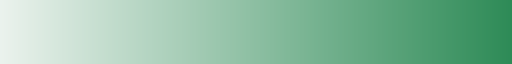

In [34]:
sns.light_palette("seagreen", as_cmap=True)

## Lets have a look at generic correlations 

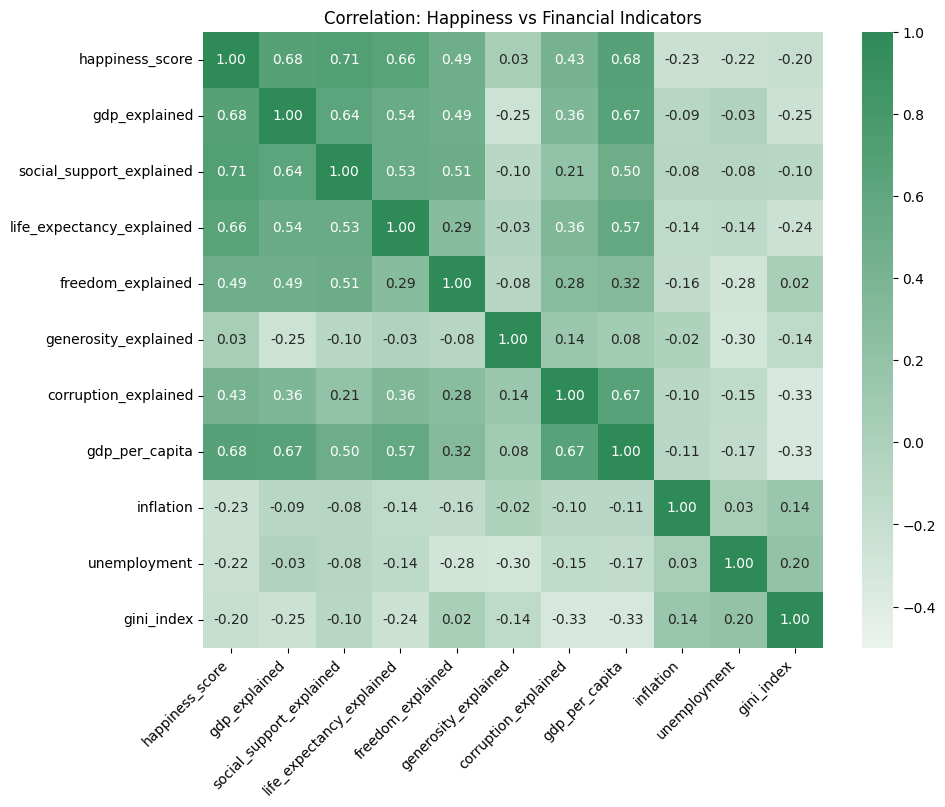

In [35]:
green_cmap = sns.light_palette("seagreen", as_cmap=True)

corr_cols = ['happiness_score', 'gdp_explained', 'social_support_explained',
             'life_expectancy_explained', 'freedom_explained', 'generosity_explained',
             'corruption_explained', 'gdp_per_capita', 'inflation', 'unemployment', 'gini_index']


plt.figure(figsize=(10, 8))
sns.heatmap(combined[corr_cols].corr(), annot=True, cmap=green_cmap, fmt='.2f', vmin=-0.5, vmax=1)
plt.xticks(rotation=45, ha='right')
plt.title('Correlation: Happiness vs Financial Indicators')
plt.show()

# Insights I want to Go into / Hypothesis 

## From the correaltions table there are a few key realtionships to explore:

### As Expected:
1. gdp/happiness
    - *richer people are generally happier*
2. social support/ happiness
    - *People who feel supported are happier*
3. life expectacy/ happiness\n
    - *People who are helther are happier*


### Unexpected
1. unemplyment/ social suppot 
    - I assumed that unemplyment would realte to people not feeling suppoted
    - Actually it shows that economic security and social connectedness are actually independant of eachother

2. Generoisty_explined / anything
    - I assumed happier and/or wealthier counties would have more generous people.
    - aginst GDP-explined there is a negative realtionship showing that the richer counties re percived, the less gernerous they are also percived
    - However teh generosity vs employment goes in the direction i'd expect as if you dont have a job it's unlikely you are going to donte to chartiy 

3. Corruption_explianed / Gini_index
    - I thought these two would be highly correlted as corruption generally means more inequlity
    - I suppose this could be an example of the difference between quantitative and qualitative data collection, as 'corrupt' Mmoney may not appear quantitativly, but if you are there, its very clear.



### Comparisons to go further into:
1. Happeniss score in realtion to inflation unemplyment and gini_index are all negative
    - They're weak but not zero and all point in the same direction
    - This suggests that higher inflation , unemplyment and inequality generally line up with lower happiness
    - This is expected but I'd be curious to know about counties that dont fit this trend

2. GDP per captia  happiness is much stronger correaltion that the realtionships of inflation, unemplyment and inequality
    - THis suggests that overall national wealth matters more to reported happiness than short-term economic conditions such as inflation, unemplyment or income distribution
    - I was more skeptical about the Gini coeffieicnt as income inequlity tends to be more sticky than unemplyment or inflation 





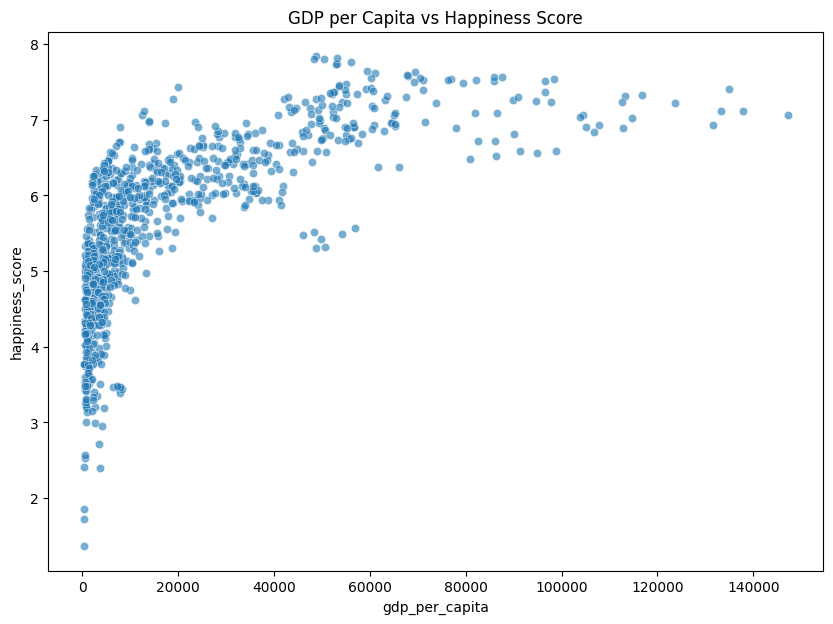

In [36]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=combined, x='gdp_per_capita', y='happiness_score', alpha=0.6)
plt.title('GDP per Capita vs Happiness Score')
plt.show()

## There is a clear trend here but there are definttely some outliers

Trend:
    - happiness increases with GDP very quikcly between 0 - 10k, then it plateaus very quikcly implying that happiness only realtes to wealth between 0 - 10k

Outliers:
    - The cluster at around 5.2 on happiness and 55k on gdp
    - Also, there are huge happiness disparities between countries with simailr gdp, I think ranking this by location would be really intresting?


In [37]:
combined[(combined['gdp_per_capita'].between(45000, 65000)) &
         (combined['happiness_score'].between(4.8, 5.6))][['country', 'report_year', 'happiness_score', 'gdp_per_capita']]

,country,report_year,happiness_score,gdp_per_capita
89,Hong Kong SAR of China,2025,5.5690,56983.066306
234,Hong Kong SAR of China,2024,5.4910,54274.754777
378,Hong Kong SAR of China,2023,5.3160,50525.111931
515,Hong Kong SAR of China,2022,5.3080,48825.027228
651,Hong Kong SAR of China,2021,5.4250,49770.564237
793,Hong Kong SAR of China,2020,5.4770,46109.229995
943,Hong Kong SAR of China,2019,5.5104,48359.001195


## Insight into why Hong Kong sits in this cluster:

- Significant political unrest during 2019 - 2020 protests, the national seurity law, and strict COVID policies during this window. 
- This rationalises why wealth isnt translating into happiness so its safe to treat this as an outlier 

## now lets see if disparites in gdp for countires with similar hppiness is realted to location

1. first we need a region column 

In [38]:
import pycountry_convert as pc

def get_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        return pc.convert_continent_code_to_continent_name(continent_code)
    except:
        return None


combined['region'] = combined['country'].apply(get_continent)
combined['region'].isnull().sum()


combined[combined['region'].isnull()]['country'].unique()


array(['Kosovo', 'Republic of Korea', 'Hong Kong SAR of China', 'Lao PDR',
       'Côte d’Ivoire', 'State of Palestine', 'DR Congo', 'North Cyprus'],
      dtype=object)

In [39]:

#manually fill in the ones pycountry_convert couldn't handle
manual_region_map = {
    'Kosovo': 'Europe',
    'Republic of Korea': 'Asia',
    'Hong Kong SAR of China': 'Asia',
    'Lao PDR': 'Asia',
    'Côte d’Ivoire': 'Africa',
    'State of Palestine': 'Asia',
    'DR Congo': 'Africa',
    'North Cyprus': 'Europe',
}

combined['region'] = combined['region'].fillna(combined['country'].map(manual_region_map))
combined['region'].isnull().sum()

0

Put it into a simple table to make visulisations

In [40]:
combined.groupby('region')[['happiness_score', 'gdp_per_capita']].mean().sort_values('happiness_score', ascending=False)

,happiness_score,gdp_per_capita
region,,
Oceania,7.106100,54300.085325
Europe,6.466107,38280.860203
North America,6.320513,17985.656872
South America,5.970044,9258.470398
Asia,5.360688,14529.157280
Africa,4.459830,2499.949878


Text(0, 0.5, 'Happiness Score')

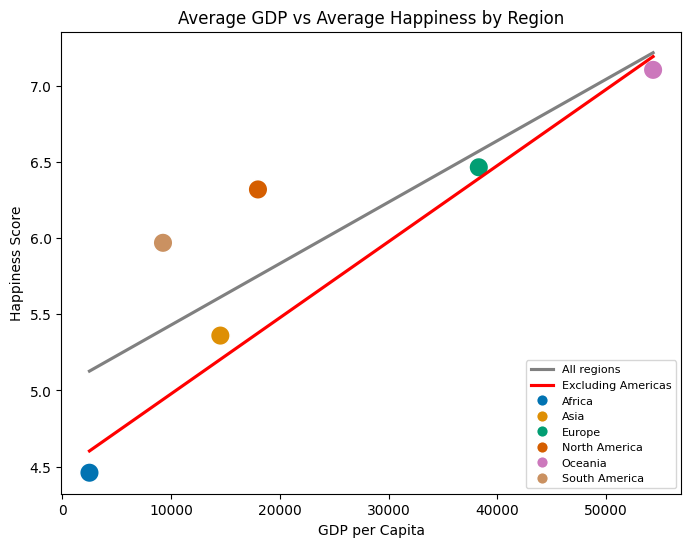

In [41]:
plt.figure(figsize=(8, 6))

region_palette = sns.light_palette("seagreen", n_colors=6)

region_avg = combined.groupby('region')[['gdp_per_capita', 'happiness_score']].mean().reset_index()


sns.regplot(data=region_avg, x='gdp_per_capita', y='happiness_score', scatter=False, color='gray', ci=None, label='All regions')

region_avg_no_americas = region_avg[~region_avg['region'].isin(['North America', 'South America'])]
sns.regplot(data=region_avg_no_americas, x='gdp_per_capita', y='happiness_score', scatter=False, color='red', ci=None, label='Excluding Americas')

sns.scatterplot(data=region_avg, x='gdp_per_capita', y='happiness_score', hue='region', palette='colorblind', s=200)
plt.legend(loc='lower right', fontsize=8, markerscale=0.6)
plt.title('Average GDP vs Average Happiness by Region')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')


- Clear Trend here and we can see ethat north America and South America are the outliers implying that they are hapier with less money 

## Time Trends across the Pandemic

- The scales for mean inflation (13) and mean happiness (0.6) vary too mcuh to put them on a single chart 
- I also took out countries like Lebanon and Zimbabwe that has insane inflation as it would skew the results 
- I did some research and foun that either indexing or z-scoring was a good was to comapre this kind of data.
    However  indexing didn't work as the small baseline 2019 value meant that an ordinary proportionte change got turned into a 
    huge percentage swing
- So I went with Z scoring which doesnt score each point realtive to its strating value, but instead against its own mean and 
    standard deviation across the whole peroid 



In [42]:
combined[combined['report_year'] == 2022].sort_values('inflation', ascending=False)[['country', 'inflation']].head(5)

,country,inflation
569,Lebanon,171.205491
567,Zimbabwe,104.705171
485,Argentina,72.430758
539,Türkiye,72.308836
545,Sri Lanka,49.721102


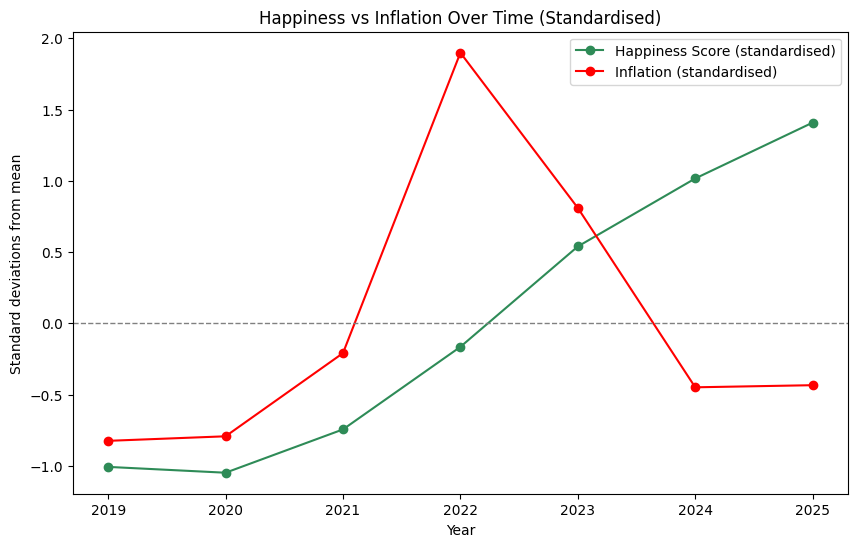

In [43]:
yearly_trends_median = combined.groupby('report_year')[['happiness_score', 'inflation']].median()

def to_zscore(series):
    return (series - series.mean()) / series.std()

standardised = yearly_trends_median.copy()
standardised['happiness_score'] = to_zscore(standardised['happiness_score'])
standardised['inflation'] = to_zscore(standardised['inflation'])

plt.figure(figsize=(10, 6))
plt.plot(standardised.index, standardised['happiness_score'], color='seagreen', marker='o', label='Happiness Score (standardised)')
plt.plot(standardised.index, standardised['inflation'], color='red', marker='o', label='Inflation (standardised)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Standard deviations from mean')
plt.xlabel('Year')
plt.title('Happiness vs Inflation Over Time (Standardised)')
plt.legend()
plt.show()

THis shows that the two, in this sample are laregely unrealted. 

I thought that higher inflation would decrese happiness but actually I think happiness **lags** inflation as teh impact of inflation is only really felt after its had time to impact
- so maybe we could expect hapiness growth to slow 